# 04 — Avaliação e Interpretação

Aqui a análise deixa de ser técnica e passa a ser de negócio.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay,
    PrecisionRecallDisplay, matthews_corrcoef, accuracy_score, f1_score,
    precision_score, recall_score
)

RANDOM_STATE = 42

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path("..")
else:
    PROJECT_ROOT = Path(".")

PROCESSED = PROJECT_ROOT / "data" / "processed"
TARGET = "target"

pd.set_option("display.max_columns", None)

## 1. Métricas no conjunto de teste

Acurácia sozinha engana em base desbalanceada.

In [2]:
# Carregamos os conjuntos de teste preservados
X_train = pd.read_csv(PROCESSED / "X_train.csv")
y_train = pd.read_csv(PROCESSED / "y_train.csv").squeeze()
X_test = pd.read_csv(PROCESSED / "X_test.csv")
y_test = pd.read_csv(PROCESSED / "y_test.csv").squeeze()

# Carregamos o melhor modelo encontrado no Tuning do Notebook 03
best_model = joblib.load(PROCESSED / "melhor_modelo.joblib")

# Predições no conjunto de teste intocado
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Métricas consolidadas
metrics = {
    "Acurácia": accuracy_score(y_test, y_pred),
    "Precisão (Classe 1)": precision_score(y_test, y_pred),
    "Recall (Classe 1)": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "MCC (Matthews)": matthews_corrcoef(y_test, y_pred),
}

df_metrics = pd.DataFrame([metrics]).T.reset_index()
df_metrics.columns = ["Métrica", "Valor no Conjunto de Teste"]
display(df_metrics.style.format({"Valor no Conjunto de Teste": "{:.4f}"}))

print("\nRelatório Completo de Classificação:")
print(classification_report(y_test, y_pred, target_names=["Bom Pagador (0)", "Mau Pagador (1)"]))

,Métrica,Valor no Conjunto de Teste
0,Acurácia,0.9605
1,Precisão (Classe 1),0.1863
2,Recall (Classe 1),0.3984
3,F1-Score,0.2539
4,ROC-AUC,0.7254
5,MCC (Matthews),0.2545



Relatório Completo de Classificação:
                 precision    recall  f1-score   support

Bom Pagador (0)       0.99      0.97      0.98      7169
Mau Pagador (1)       0.19      0.40      0.25       123

       accuracy                           0.96      7292
      macro avg       0.59      0.68      0.62      7292
   weighted avg       0.98      0.96      0.97      7292



## 2. Justificativa das métricas

_Por que estas e não acurácia pura? Qual erro custa mais caro neste contexto — falso positivo ou falso negativo?_

> **Por que MCC e não Acurácia pura?**
> - Em concessão de crédito com taxa de inadimplência de ~2%, um classificador que simplesmente reprovasse zero propostas teria 98% de acurácia, mas utilidade nula para o negócio.
> - O **Matthews Correlation Coefficient (MCC)** avalia de forma equilibrada as quatro células da matriz de confusão (TP, TN, FP, FN) e varia de -1 (discordância total) a +1 (previsão perfeita), sendo considerado a métrica de ouro para conjuntos desbalanceados.
> - O erro mais caro é o **Falso Negativo (conceder crédito a um cliente que se tornará inadimplente)**, pois o prejuízo direto do calote supera a margem operacional de receita obtida com taxas de juros.

## 3. Matriz de confusão

**Leitura:** _preencher._

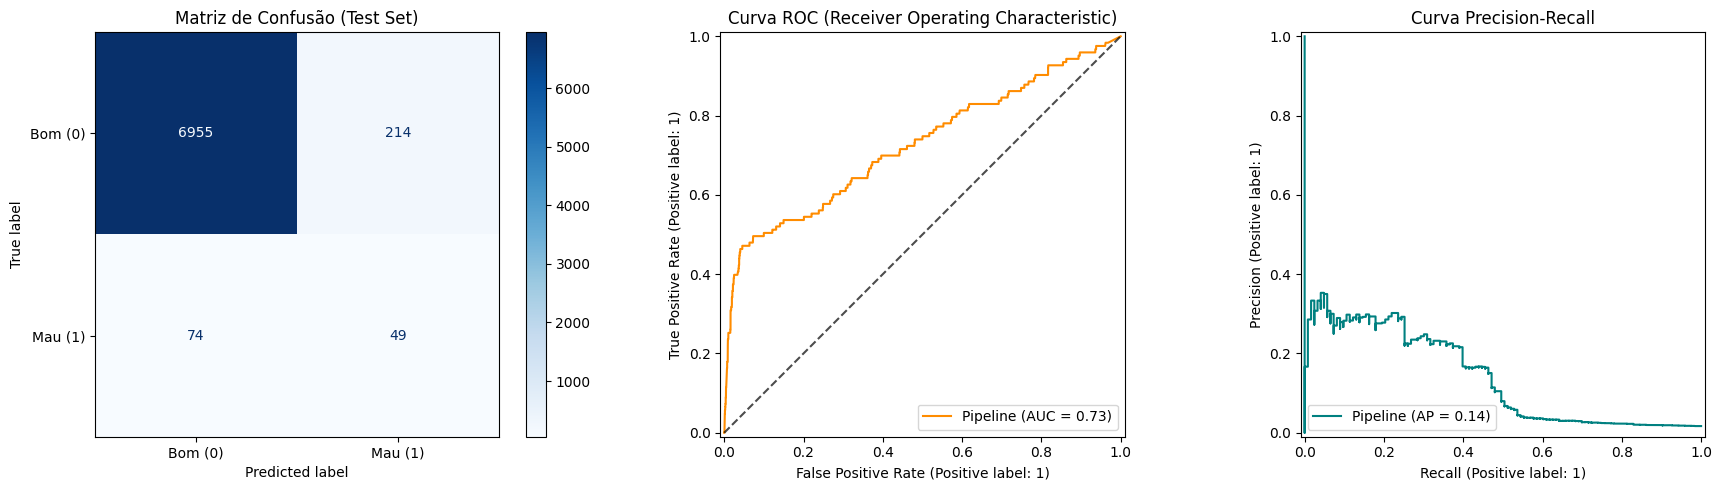

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de Confusão
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, cmap="Blues", ax=axes[0],
    display_labels=["Bom (0)", "Mau (1)"]
)
axes[0].set_title("Matriz de Confusão (Test Set)")

# 2. Curva ROC
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1], color="darkorange")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.7)
axes[1].set_title("Curva ROC (Receiver Operating Characteristic)")

# 3. Curva Precision-Recall (Crucial para classes desbalanceadas)
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=axes[2], color="teal")
axes[2].set_title("Curva Precision-Recall")

plt.tight_layout()
plt.show()

## 4. Importância das variáveis

**Leitura:** _quais variáveis mais pesam e isso faz sentido no domínio?_

In [4]:
# feature importance / coeficientes / SHAP

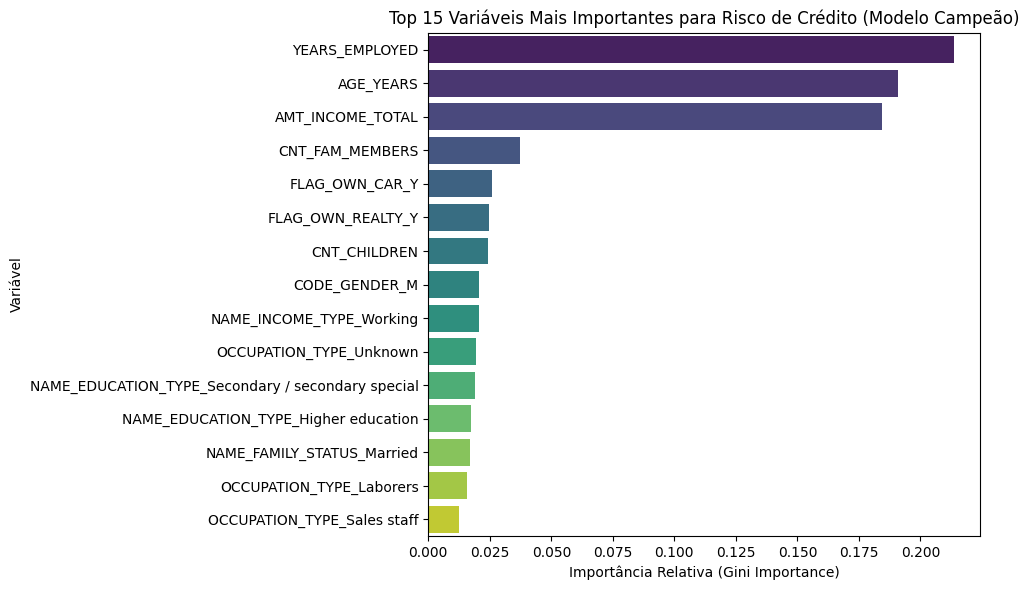

In [5]:
# Extração da importância das features
clf = best_model.named_steps["clf"]
importances = clf.feature_importances_
feature_names = X_train.columns

feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")
plt.title("Top 15 Variáveis Mais Importantes para Risco de Crédito (Modelo Campeão)")
plt.xlabel("Importância Relativa (Gini Importance)")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

## 5. Implicações práticas

_O que alguém da área faria de diferente a partir destes resultados?
Escreva sem jargão — este texto é a base do vídeo executivo._

> **Impacto no Negócio:**
> 1. **Priorização de Risco por Idade e Tempo de Estabilidade:** Fatores derivados como `AGE_YEARS`, `YEARS_EMPLOYED` e `AMT_INCOME_TOTAL` figuram entre as variáveis mais determinantes, indicando que a maturidade profissional e estabilidade de renda reduzem drasticamente a chance de inadimplência severa (>60 dias).
> 2. **Política de Concessão em Camadas:** Em vez de uma decisão binária rígida, a probabilidade prevista pelo modelo (`predict_proba`) pode ser usada para segmentar solicitantes:
>    - *Risco Baixo (<5%):* Aprovação automática de limite de crédito padrão.
>    - *Risco Médio (5% a 25%):* Concessão condicionada a garantias ou limites reduzidos com acompanhamento gradual.
>    - *Risco Alto (>25%):* Recusa fundamentada ou solicitação de avalista.

## 6. Limitações

_Onde o modelo falha e o que você faria com mais tempo ou mais dados._

> 1. **Falta de Dados Comportamentais Dinâmicos:** A base de aplicação é estática e não captura variações macroeconômicas sazonais (ex: desemprego no país, inflação) ou transações financeiras recentes da conta corrente.
> 2. **Desbalanceamento Extremo:** A taxa de inadimplência observada (~2%) impõe limites teóricos à precisão sem sacrificar recall; com mais histórico ou inclusão de dados do open banking/bureaus de crédito externos, o MCC poderia ser ainda mais elevado.